<a href="https://colab.research.google.com/github/abcdon21/Deep-Learning-/blob/main/CNN_handwritten_digits.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
# from google.colab import files
# uploaded= files.upload()

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [34]:
img=np.array([0,0,0,0,122,255,0,0,0]).reshape(3,3)
img



array([[  0,   0,   0],
       [  0, 122, 255],
       [  0,   0,   0]])

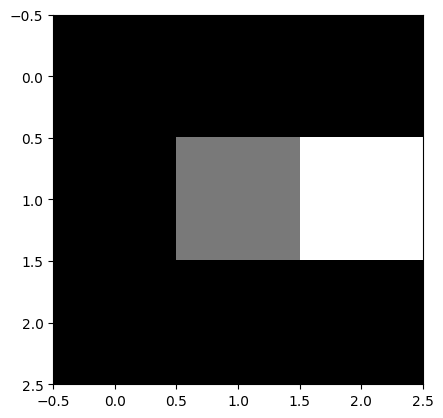

In [35]:
plt.imshow(img,cmap='gray') #imshow is IMAGE SHOW


MNIST HANDWRITTEN DIGIT DATASET

In [36]:
import tensorflow as tf

tf.keras.datasets.mnist #modified national institute of technology

<module 'keras.datasets.mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/mnist/__init__.py'>

In [37]:
(X_train,y_train),(X_test,y_test)=tf.keras.datasets.mnist.load_data()

In [38]:
X_train.shape

(60000, 28, 28)

In [39]:
y_train.shape

(60000,)

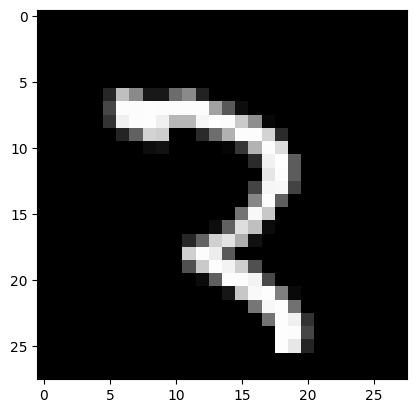

In [40]:
plt.imshow(X_train[500],cmap='gray')

In [41]:
print(y_train[505])

7


CNN

In [42]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Flatten,Conv2D,MaxPooling2D

In [43]:
#not necessary but in order to prevent future errors
X_train=X_train.reshape(60000,28,28,1) #one single image is of 28*28 and converting it into 4d array-by combining two 3d array
X_test=X_test.reshape(10000,28,28,1)

NORMALIZATION

In [44]:
#min max scaling-> going to change range from 0-255 to 0-1 where formula is x-min/max-min
# from sklearn.preprocessing import MinMaxScaler
# scaler=MinMaxScaler()
# X_train=scaler.fit_transform(X_train)
# X_test=scaler.transform(X_test)

#OR

X_train=X_train/255
X_test=X_test/255

MODEL BULDING

In [45]:
model=Sequential()


In [46]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [47]:
#kernel size on each image
model.add(Conv2D(kernel_size=(3,3),input_shape=(28,28,1),filters=32,activation='relu')) # every photo has 32 features(color,shape,size....)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [48]:
#POOLING
model.add(MaxPooling2D(pool_size=(2,2)))

Flatten from 2d to 1d

In [49]:
model.add(Flatten())

In [50]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 5408)           │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 320 (1.25 KB)

 Trainable params: 320 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

CNN ENDS HERE NOW CLASSIFICATION

In [51]:
#input layer
model.add(Dense(128,activation='relu'))

#output layer
model.add(Dense(10,activation='softmax'))

#architecture is ready

compilation

In [52]:
model.compile(loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
model.fit(X_train,y_train,epochs=10,validation_data=(X_test,y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 48s 25ms/step - accuracy: 0.9554 - loss: 0.1477 - val_accuracy: 0.9797 - val_loss: 0.0594
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 22ms/step - accuracy: 0.9842 - loss: 0.0524 - val_accuracy: 0.9852 - val_loss: 0.0465
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9896 - loss: 0.0358 - val_accuracy: 0.9848 - val_loss: 0.0437
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9927 - loss: 0.0243 - val_accuracy: 0.9866 - val_loss: 0.0438
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 43s 23ms/step - accuracy: 0.9945 - loss: 0.0174 - val_accuracy: 0.9874 - val_loss: 0.0432
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 81s 22ms/step - accuracy: 0.9966 - loss: 0.0117 - val_accuracy: 0.9870 - val_loss: 0.0485
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9975 - loss: 0.0084 - val_accuracy: 0.9835 - val_loss: 0.0650
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9984 -